# Ex. D3: RCPSP Examples

We study a Resource Constrained Project Scheduling Problem (RCPSP).

**Release Notes**

- 20260325: this is a simple,  explicit RCPSP version, based on [post](https://medium.com/python-in-plain-english/solving-the-resource-constrained-project-scheduling-problem-rcpsp-with-python-and-pyomo-001cffd5344a)

## RCPSP

Recall the setting.

The main objective for the RCPSP is to find the optimal feasible schedule, that produces the *minimum* project duration (or any function of the duration, such as *cost*) while respecting all of the *precedence* and *resource* constraints.

The RCPSP has the following input data: $\mathcal{J}$ set of jobs, $\mathcal{R}$ set of renewable resources, $\mathcal{S}$ set of precedences between jobs $(i,j)\in\mathcal{J}\times\mathcal{J},$ $\mathcal{T}$ planning horizon set of possible processing times for jobs, $p_{j}$ processing time of job $j,$ $u_{(j,r)}$ amount of resource $r$ required for processing job $j,$ $c_{r}$ capacity of renewable resource $r.$

There are many different Mixed Integer Linear Programming (MILP) formulations for the RCPSP (at least 12). We choose the most suitable, discrete-time (DT) formulation. This is a binary formulation where we have:

- one binary variable $x_{i,t}$ for each activity $i$ and starting time/date $t.$
-  $x_{i,t} = \begin{cases} 1, \quad \text{if activity i starts on day/time t,} \\ 0, \quad  \text{otherwise.}  \end{cases}$ 
-  The total number of variables is equal to the number of project activities (plus two extra dummy activities – one for the project ‘Start’ and one for the project ‘End’) multiplied by the number of possible start dates $t.$
-  The number of possible start dates is determined by the project time horizon $T,$ which represents the maximum possible project duration.
-  Each task has a duration $p_i$ and a resource consumption $u_{i,k}$ for each resource $k.$
-   Precedence constraints are provided as a list of tuples $E$ in the form $(i,j),$ indicating that task $j$ cannot start until task $i$ is finished.

The optimization problem is then,

$$
\begin{align}
\text{Minimize} \quad &  \sum_{t\in \mathcal{T}} t\cdot x_{(n+1,t)} & (1)\\
\text{Subject to:} \quad & 
 \sum_{t\in \mathcal{T}} x_{(j,t)}  = 1  \,\,\, \forall j\in J & (2)\\
 & \sum_{j\in J} \sum_{t_2=t-p_{j}+1}^{t} u_{(j,r)}x_{(j,t_2)}  \leq c_{r}  \,\,\, \forall t\in \mathcal{T}, r \in R & (3) \\
 & \sum_{t\in \mathcal{T}} t\cdot x_{(s,t)} - \sum_{t \in \mathcal{T}} t\cdot x_{(j,t)}  \geq p_{j}  \,\,\, \forall (j,s) \in S & (4)\\
& x_{(j,t)}  \in \{0,1\} \,\,\, \forall j\in J, t \in \mathcal{T} & (5)
\end{align}$$

1. The objective function (1) represents the sum of all possible start dates for the dummy variable $x_{n+1,t}$ (where these dummy variables represent the project’s end date). We know that only one of these variables will equal 1 for a specific $t.$ Therefore, by minimizing the sum of the product $t*x_{n+1,t},$ we are effectively minimizing the project duration.
2. Constraint (2) ensures that each activity $i$ has exactly one start date.
3. Constraint (3) guarantees that for any time period $t,$ the schedule does not exceed the capacity $c_r$ for any resource $r.$
4. Finally, constraint (4)  ensures that if an activity $j$ follows another activity $i,$ then activity $j$ must start after the finish date/time of activity $i,$ which is equal to the start date/time of $i$ plus its duration $p_i.$

### Naive implementation

We consider a workflow with

- 10 tasks,
- durations,
- precedence relations from the DAG,
- 3 resources [r1, r2, r3], for example [cpu, gpu, mem].

![](DAG1.webp)

**Tabular data:** job, duration, resource requirements, precedences.

| **Job** | **Duration** | **Resource** | **Precedence** |   |
|---------|:------------:|:------------:|:--------------:|---|
| A       |       5      |    [1,0,0]   |        -       |   |
| B       |       2      |    [1,0,0]   |        -       |   |
| C       |       5      |    [0,1,0]   |        A       |   |
| D       |       6      |    [0,0,1]   |        B       |   |
| ...       |       ...      |    ...   |       ...      |   |

In [1]:
import pandas as pd #handling dataframes
import numpy as np  #numpy for array management
import matplotlib.pyplot as plt #plotting
import plotly.express as px #generate interactive plots
from datetime import timedelta, date, datetime # datetimes processing
from itertools import chain, combinations, permutations, product

#pyomo.environ provides the framework for building the model
import pyomo.environ as pyo 

#SolverFactory allows to call the solver
from pyomo.opt import SolverFactory 

#store the solver in a variable to call it later, we need to tell google colab
#the specific path on which the solver was installed
opt_glpk = pyo.SolverFactory('glpk') #, executable='/opt/homebrew/bin/glpsol')

### Input Data

We use a very simple input format, for illustrative purposes. Thsi will be improved below, to draw the GANTT chart.

In [2]:
activities =  {0:'Start',
               1: 'A',
               2: 'B',
               3: 'C',
               4: 'D',
               5: 'E',
               6: 'F',
               7: 'G',
               8: 'H',
               9: 'I',
               10: 'J',
               11:'End'}
p = [0, 5, 2, 5, 6, 5, 2, 3, 2, 4, 3, 0] # activity durations

u = [[0, 0, 0], # list of resource consumptions
     [1, 0, 0],
     [1, 0, 0],
     [0, 1, 0],
     [0, 0, 1],
     [0, 1, 0],
     [0, 1, 0],
     [0, 0, 1],
     [0, 0, 1],
     [0, 0, 1],
     [0, 0, 1],
     [0, 0, 0]]

E = [[0, 1], # list of precedence constraints
    [0, 2],
    [1, 3],
    [2, 4],
    [3, 5],
    [3, 6],
    [3, 7],
    [5, 8],
    [6, 9],
    [8, 10],
    [9, 10],
    [4, 11],
    [7, 11],
    [10, 11]]

c = [1,1,1] # max resource capacity

### Better input format

A more general (and elegant) input format is to use a dictionary. Here we convert the input `dict` to a `pandas` dataframe for easier plotting of the GANTT chart.

It is advisable to ese better `pyomo`  syntax, with dict's and decorators and then use disjunctions for the sequencing.

Each task is described here by:
- "drt" = duration
- "prc" = precedence
- "rsc" = resource

In [3]:
JOBS = pd.DataFrame(
    {
    "A": {"drt": 5, "prc": None,       "rsc": [1, 0, 0] },
    "B": {"drt": 2, "prc": None,       "rsc": [1, 0, 0] },
    "C": {"drt": 5, "prc": "A",        "rsc": [0, 1, 0] },
    "D": {"drt": 6, "prc": "B",        "rsc": [0, 0, 1] },
    "E": {"drt": 5, "prc": "C",        "rsc": [0, 1, 0] },
    "F": {"drt": 5, "prc": "C",        "rsc": [0, 1, 0] },
    "G": {"drt": 5, "prc": "C",        "rsc": [0, 0, 1] },
    "H": {"drt": 5, "prc": "E",        "rsc": [0, 0, 1] },
    "I": {"drt": 5, "prc": "F",        "rsc": [0, 0, 1] },
    "J": {"drt": 5, "prc": ("H", "I"), "rsc": [0, 0, 1] }
    }
).T

c = [1,1,1] # max resource capacity

Compute naive time horizon and ranges we will need

In [4]:
n = len(p) - 2
ph = sum(p)
# Resources, Jobs, Times
(R, J, T) = (range(len(c)), range(len(p)), range(ph))

Build the pyomo model.

In [5]:
model = pyo.ConcreteModel() # create empty model 
# decision variables
model.J  = pyo.RangeSet(0,len(p)-1) # set for the activities
model.T  = pyo.RangeSet(0,ph) # set for the days in the planning horizon
model.Xs = pyo.Var(model.J, model.T, within = pyo.Binary) # variables
Xs = model.Xs

# Objective, eq. (1)
# sum of the dates for the final activity (the dummy end)
Z = sum([t*Xs[(n+1,t)] for t in model.T]) 
# we want to minimize this objective function
model.obj = pyo.Objective(expr = Z, sense=pyo.minimize)

# Constraint (2): Only one start time
model.one_xs = pyo.ConstraintList() #create a list of constraints
for j in model.J:
  #add constraints to the list created above
  model.one_xs.add(expr = sum(Xs[(j,t)] for t in model.T)==1)

# Constraint (3): Resource capacity constraints
model.rl = pyo.ConstraintList() #resource level constraints
for (r, t) in product(R, T):
  model.rl.add(expr = sum(u[j][r]*Xs[(j,t2)] for j in model.J for t2 in range(max(0, t - p[j] + 1), t + 1)) <= c[r])

# Constraint (4): Precedence constraints
model.pc = pyo.ConstraintList() # precedence constraints
for (j,s) in  E:
  model.pc.add(expr = sum(t*Xs[(s,t)] - t*Xs[(j,t)] for t in model.T) >= p[j])

Solve the problem

In [6]:
opt_glpk.options['tmlim'] = 60
opt_glpk.options["mipgap"] = 0
results = opt_glpk.solve(model,tee=True) # ask the solver to solve the model
results.write()

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --tmlim 60 --mipgap 0 --write /var/folders/kx/_1g1vzv51nq1yv81c377flsr0000gn/T/tmp53249h8l.glpk.raw
 --wglp /var/folders/kx/_1g1vzv51nq1yv81c377flsr0000gn/T/tmp9ed9669j.glpk.glp
 --cpxlp /var/folders/kx/_1g1vzv51nq1yv81c377flsr0000gn/T/tmpsaes6nmz.pyomo.lp
Reading problem data from '/var/folders/kx/_1g1vzv51nq1yv81c377flsr0000gn/T/tmpsaes6nmz.pyomo.lp'...
/var/folders/kx/_1g1vzv51nq1yv81c377flsr0000gn/T/tmpsaes6nmz.pyomo.lp:3715: warning: lower bound of variable 'x40' redefined
/var/folders/kx/_1g1vzv51nq1yv81c377flsr0000gn/T/tmpsaes6nmz.pyomo.lp:3715: warning: upper bound of variable 'x40' redefined
137 rows, 456 columns, 2801 non-zeros
456 integer variables, all of which are binary
4171 lines were read
Writing problem data to '/var/folders/kx/_1g1vzv51nq1yv81c377flsr0000gn/T/tmp9ed9669j.glpk.glp'...
3571 lines were written
GLPK Integer Optimizer 5.0
137 rows, 456 columns, 2801 non-zeros
456 integer variables,

In [7]:
# Extract and print the optimal schedule
SCHEDULE = {}
for (j, t) in product(J, T):

  if pyo.value(Xs[(j, t)]) >= 0.99: #only get the x values == 1
    a = activities[j]
    SCHEDULE[a] = {'s':t,'f':t+p[j]}
    print(f'Activity {j}, begins at t={t} and finishes at {t+p[j]}')

out = pd.DataFrame(SCHEDULE).T
SCHEDULE = out.T.to_dict()

Activity 0, begins at t=0 and finishes at 0
Activity 1, begins at t=2 and finishes at 7
Activity 2, begins at t=0 and finishes at 2
Activity 3, begins at t=7 and finishes at 12
Activity 4, begins at t=4 and finishes at 10
Activity 5, begins at t=14 and finishes at 19
Activity 6, begins at t=12 and finishes at 14
Activity 7, begins at t=12 and finishes at 15
Activity 8, begins at t=19 and finishes at 21
Activity 9, begins at t=15 and finishes at 19
Activity 10, begins at t=21 and finishes at 24
Activity 11, begins at t=24 and finishes at 24


In [8]:
# Add dates to the dict
#start_date = datetime.date(2023, 1, 11)
start_date = date.today()

SCHEDULE_DF = pd.DataFrame(SCHEDULE).T
SCHEDULE_DF['Start_Date'] = [str(start_date + timedelta(days=s)) for s in SCHEDULE_DF['s']]
SCHEDULE_DF['Finish_Date'] =[str(start_date + timedelta(days=f)) for f in SCHEDULE_DF['f']]

In [9]:
def gantt(jobs, schedule):
    w = 0.25  # bar width
    plt.rcParams.update({"font.size": 13})
    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(13, 2*0.7 * len(jobs.index)),
                           tight_layout=True)
    # Jobs plot
    for k, job in enumerate(jobs.index):
        s = schedule.loc[job, "s"]
        f = schedule.loc[job, "f"]
        # Show job start-finish window
        color = "g" #if f <= d else "r"
        axs[0].fill_between(
            [s, f], [-k - w, -k - w], [-k + w, -k + w], color=color, alpha=0.6
        )
        axs[0].text(
            (s + f) / 2.0,
            -k,
            "Job " + job,
            color="white",
            weight="bold",
            ha="center",
            va="center",
        )

    axs[0].set_ylim(-len(jobs.index), 1)
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Jobs")
    axs[0].set_yticks([0,-1,-2,-3,-4,-5,-6,-7,-8,-9],['A','B','C','D','E','F','G','H','I','J'])
    #axs[0].set_yticks(range(len(jobs)), jobs.index[::-1])
    axs[0].spines["right"].set_visible(False)
    #axs[0].spines["left"].set_visible(False)
    axs[0].spines["top"].set_visible(False)
    axs[0].set_title('Job Schedule')
    axs[0].grid()

    # Machines plot
    SCHEDULE = schedule.T.to_dict()
    for j in SCHEDULE.keys():
        if 'machine' not in SCHEDULE[j].keys():
                SCHEDULE[j]['machine'] = 1
    MACHINES = sorted(set([SCHEDULE[j]['machine'] for j in SCHEDULE.keys()]))
    #for j in sorted(SCHEDULE.keys()):
    for k, j in enumerate(JOBS.index):
        idx = MACHINES.index(SCHEDULE[j]['machine'])
        x = SCHEDULE[j]['s']
        y = SCHEDULE[j]['f']
        axs[1].fill_between([x,y],[idx-w,idx-w],[idx+w,idx+w], color='blue', alpha=0.5)
        axs[1].plot([x,y,y,x,x], [idx-w,idx-w,idx+w,idx+w,idx-w],lw=0.5, color='k')
        axs[1].text((SCHEDULE[j]['s'] + SCHEDULE[j]['f'])/2.0,idx,
            'Job ' + j, color='white', weight='bold',
            horizontalalignment='center', verticalalignment='center')
    xlim = axs[0].get_xlim()
    axs[1].set_xlim(xlim)
    axs[1].set_ylim(-0.5, len(MACHINES)-0.5)
    axs[1].set_yticks(range(len(MACHINES)), MACHINES)

    
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Machines")
    axs[1].spines["right"].set_visible(False)
    #axs[1].spines["left"].set_visible(False)
    axs[1].spines["top"].set_visible(False)
    axs[1].set_aspect(3)
    axs[1].set_title('Machine Schedule', pad=30)

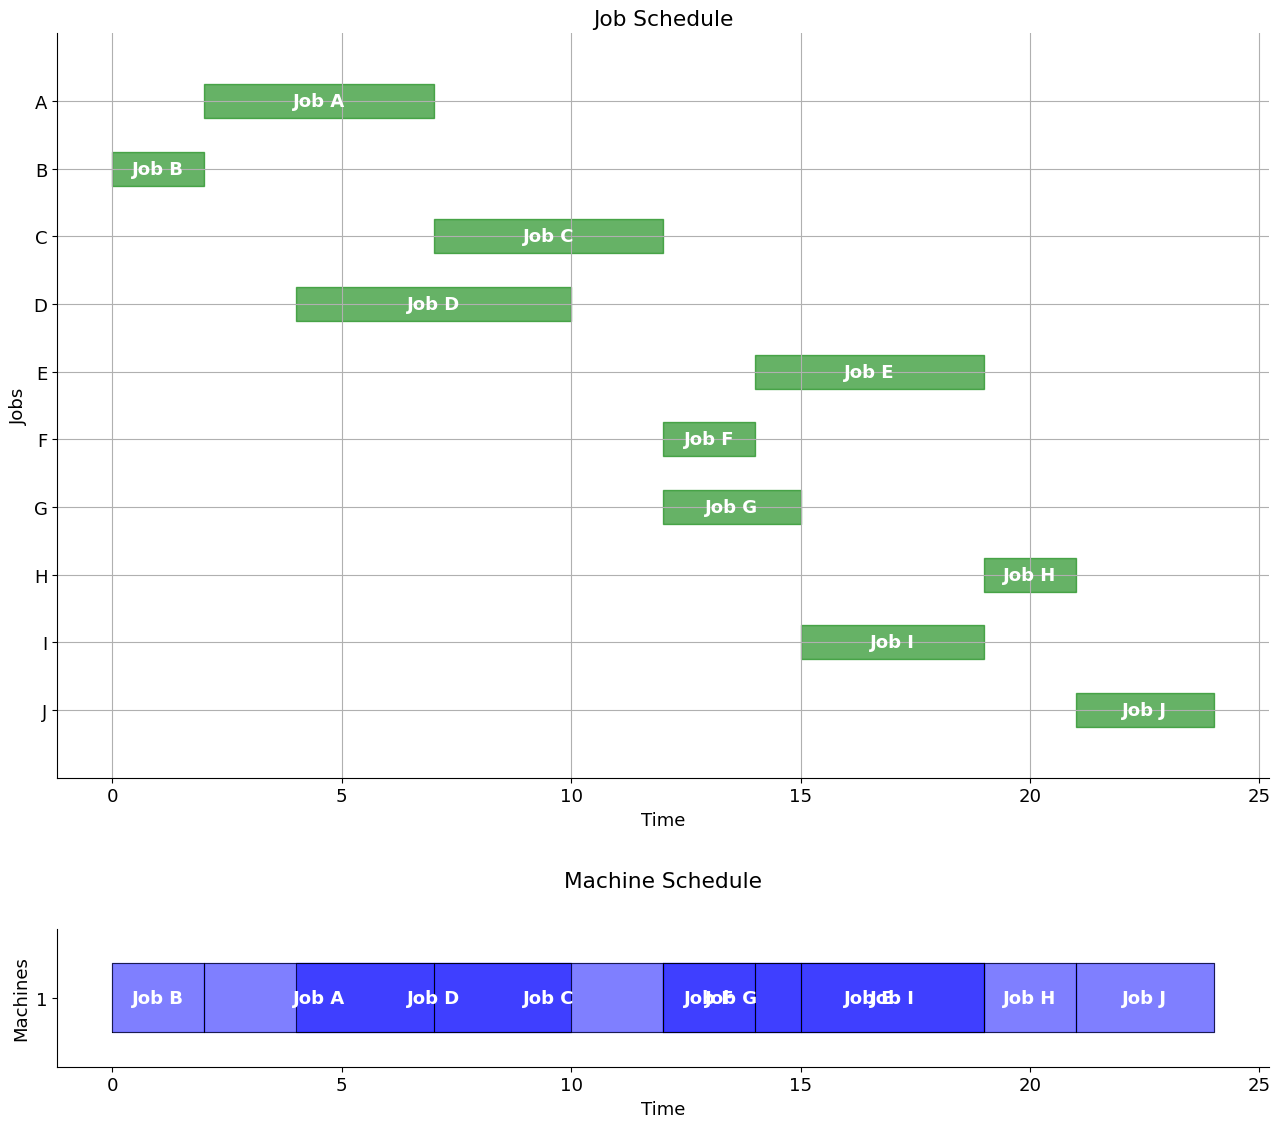

In [10]:
gantt(JOBS, pd.DataFrame(SCHEDULE).T)

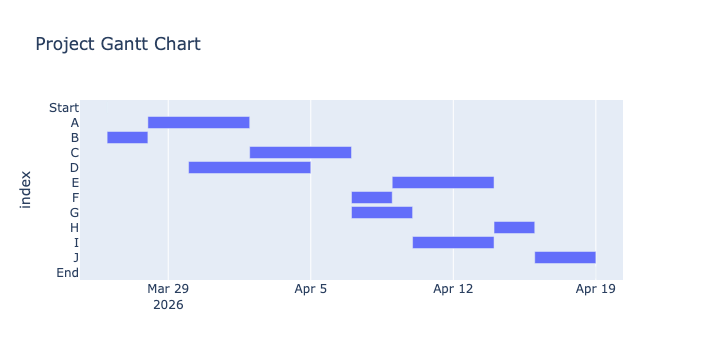

In [11]:
# Output the plotly GANTT chart
fig = px.timeline(SCHEDULE_DF, 
                  x_start="Start_Date", 
                  x_end="Finish_Date", 
                  y=SCHEDULE_DF.index,title='Project Gantt Chart')
fig.update_yaxes(autorange="reversed") # otherwise tasks are listed from the bottom up
fig.write_html("sched-03-RCPSP-Gantt_chart.html")
fig.show()

### Output

Finally, save the optimal schedule to a CSV file (for example).

In [ ]:
#SCHEDULE_DF.to_csv('D3-RCPSP-output_schedule.csv') #export csv file

## RCPSP with better syntax

### Input data

Use better `pyomo`  syntax, with dict's and decorators. Use disjunctions for the sequencing.

Each task is described by:
- "drt" = duration
- "prc" = precedence
- "rsc" = resource

In [ ]:
TASKS = {
    "A": {"drt": 5, "prc": None,       "rsc": [1, 0, 0] },
    "B": {"drt": 2, "prc": None,       "rsc": [1, 0, 0] },
    "C": {"drt": 5, "prc": "A",        "rsc": [0, 1, 0] },
    "D": {"drt": 6, "prc": "B",        "rsc": [0, 0, 1] },
    "E": {"drt": 5, "prc": "C",        "rsc": [0, 1, 0] },
    "F": {"drt": 5, "prc": "C",        "rsc": [0, 1, 0] },
    "G": {"drt": 5, "prc": "C",        "rsc": [0, 0, 1] },
    "H": {"drt": 5, "prc": "E",        "rsc": [0, 0, 1] },
    "I": {"drt": 5, "prc": "F",        "rsc": [0, 0, 1] },
    "J": {"drt": 5, "prc": ("H", "I"), "rsc": [0, 0, 1] }
}

c = [1,1,1] # max resource capacity

Now, define a `pyomo` function that takes a dictionary of tasks as input, and returns a Pyomo model.

In [ ]:
from pyomo.environ import *

def jobshop_model(TASKS):
    
    model = ConcreteModel()

    # tasks is a two dimensional set of (j,m) constructed from the dictionary keys
    model.TASKS = Set(initialize = TASKS.keys(), dimen=2)
    
    # the set of jobs is constructed from a python set
    model.JOBS = Set(initialize = list(set([j for (j,m) in model.TASKS])))
    
    # set of machines is constructed from a python set
    model.MACHINES = Set(initialize = list(set([m for (j,m) in model.TASKS])))
    
    # the order of tasks is constructed as a cross-product of tasks and filtering
    model.TASKORDER = Set(initialize = model.TASKS * model.TASKS, dimen=4, 
        filter = lambda model, j, m, k, n: (k,n) == TASKS[(j,m)]['prc'])
    
    # the set of disjunctions is cross-product of jobs, jobs, and machines
    model.DISJUNCTIONS = Set(initialize = model.JOBS * model.JOBS * model.MACHINES, dimen=3,
        filter = lambda model, j, k, m: j < k and (j,m) in model.TASKS and (k,m) in model.TASKS)
    
    # load duration data into a model parameter for later access
    model.dur = Param(model.TASKS, initialize=lambda model, j, m: TASKS[(j,m)]['drt'])

    # establish an upper bound on makespan
    ub = sum([model.drt[j, m] for (j,m) in model.TASKS])
    
    # create decision variables
    model.makespan = Var(bounds=(0, ub))
    model.start = Var(model.TASKS, bounds=(0, ub))
    
    model.objective = Objective(expr = model.makespan, sense = minimize)

    model.finish = Constraint(model.TASKS, rule=lambda model, j, m:  
        model.start[j,m] + model.dur[j,m] <= model.makespan)
    
    model.preceding = Constraint(model.TASKORDER, rule=lambda model, j, m, k, n: 
        model.start[k,n] + model.dur[k,n] <= model.start[j,m])
    
    model.disjunctions = Disjunction(model.DISJUNCTIONS, rule=lambda model,j,k,m:
        [model.start[j,m] + model.dur[j,m] <= model.start[k,m], 
         model.start[k,m] + model.dur[k,m] <= model.start[j,m]])
    
    TransformationFactory('gdp.hull').apply_to(model)
    return model

jobshop_model(TASKS)